# Test 1: Torus KSWGD and DMPS

The numerical routines are imported from shared Python modules, while this notebook keeps the torus experiment settings and the original-style visual diagnostics.

In [1]:
from dataclasses import replace
from pathlib import Path
import time

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

from plotting_utils import setup_plot_style, ensure_dir, save_figure, finish_layout, polish_axes

setup_plot_style(scale=1.5)
np.random.seed(42)

from systems import TorusConfig, sample_torus, torus_sde_step, init_torus_particles, cartesian_to_angles
from kswgd import fit_spectral_model, run_kswgd
from dmps import fit_dmps, run_dmps
from baseline import mmd_rbf, sliced_wasserstein, torus_phi_tv
from experiment_plots import plot_torus_triptych, plot_torus_angular, plot_torus_overlap_matrix

# Legacy torus settings from the original successful notebooks.
R = 2.0
r = 0.8
KERNEL_TYPE = 1  # 1: RBF/Gaussian
DT_SNAPSHOT = 0.05
H_KSWGD = 0.005
THETA_INIT_CENTER = 0.0
PHI_INIT_CENTER = np.pi / 2
THETA_SPREAD = 0.3
PHI_SPREAD = 0.3
N_TARGET = 800
N_PARTICLES = 2000
N_ITER = 5000
MAX_MODES = 80
MAX_STEP_NORM = None
USE_GPU = True
SNAPSHOT_STEPS = [0, N_ITER // 2, N_ITER]

cfg = TorusConfig(
    R=R, r=r, n_target=N_TARGET, n_particles=N_PARTICLES, n_iter=N_ITER,
    step_size=H_KSWGD, dt_edmd=DT_SNAPSHOT, theta_init_center=THETA_INIT_CENTER,
    phi_init_center=PHI_INIT_CENTER, theta_spread=THETA_SPREAD,
    phi_spread=PHI_SPREAD, seed=42,
)
ensure_dir('figures/torus')
print(cfg)


TorusConfig(R=2.0, r=0.8, n_target=800, n_particles=2000, n_iter=5000, step_size=0.005, dt_edmd=0.05, theta_init_center=0.0, phi_init_center=1.5707963267948966, theta_spread=0.3, phi_spread=0.3, seed=42)


In [2]:
start = time.time()
X_tar, theta_tar, phi_tar = sample_torus(cfg)
X_next, theta_next, phi_next = torus_sde_step(theta_tar, phi_tar, cfg)
X_init = init_torus_particles(cfg)
theta_init, phi_init = cartesian_to_angles(X_init, cfg.R, cfg.r)

kswgd_model = fit_spectral_model(X_tar, X_next, max_modes=MAX_MODES, method='KSWGD')
dmps_model = fit_dmps(X_tar, max_modes=MAX_MODES)
print(f'Target samples: {X_tar.shape}; particles: {X_init.shape}; prepared in {time.time() - start:.2f}s')
print(f'KSWGD epsilon={kswgd_model.epsilon:.6f}; DMPS epsilon={dmps_model.epsilon:.6f}')


Target samples: (800, 3); particles: (2000, 3); prepared in 0.99s
KSWGD epsilon=0.699372; DMPS epsilon=0.699372


In [3]:
kswgd_result = run_kswgd(
    kswgd_model, X_init, n_iter=N_ITER, step_size=H_KSWGD, snapshot_steps=SNAPSHOT_STEPS,
    use_gpu=USE_GPU, torus=(cfg.R, cfg.r), max_step_norm=MAX_STEP_NORM, progress=False,
)
dmps_result = run_dmps(
    dmps_model, X_init, n_iter=N_ITER, step_size=H_KSWGD, snapshot_steps=SNAPSHOT_STEPS,
    use_gpu=USE_GPU, torus=(cfg.R, cfg.r), max_step_norm=MAX_STEP_NORM, progress=False,
)

for name, X in {'KSWGD': kswgd_result.final, 'DMPS': dmps_result.final}.items():
    print(f"{name}: MMD={mmd_rbf(X_tar, X):.4f}, SW={sliced_wasserstein(X_tar, X, seed=cfg.seed):.4f}, phi-TV={torus_phi_tv(X, cfg.R, cfg.r):.4f}")


KSWGD: MMD=0.0337, SW=0.0639, phi-TV=0.1208


DMPS: MMD=0.4985, SW=1.4536, phi-TV=0.6342


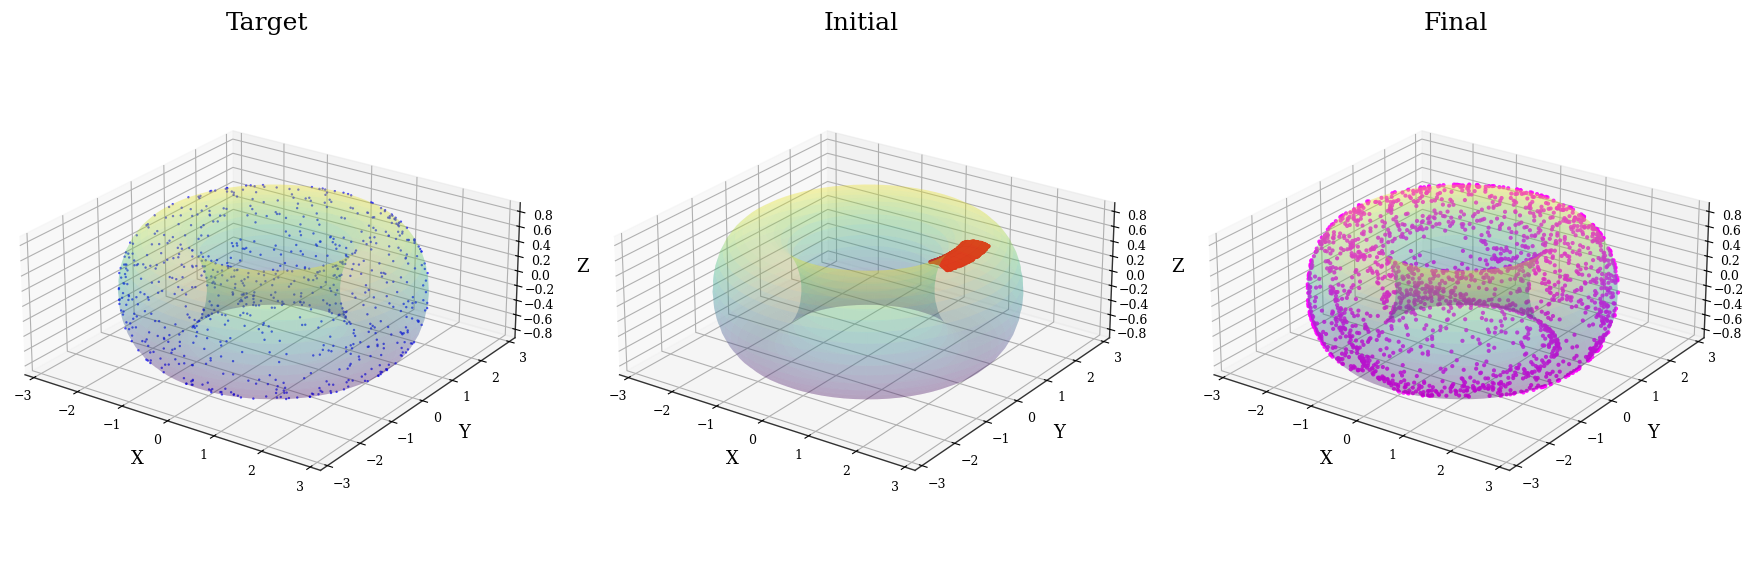

Caption: KSWGD on the torus: target samples, localized initial particles, and final transported particles.
Saved: figures/torus/kswgd_torus_results.png and figures/torus/kswgd_torus_results.pdf


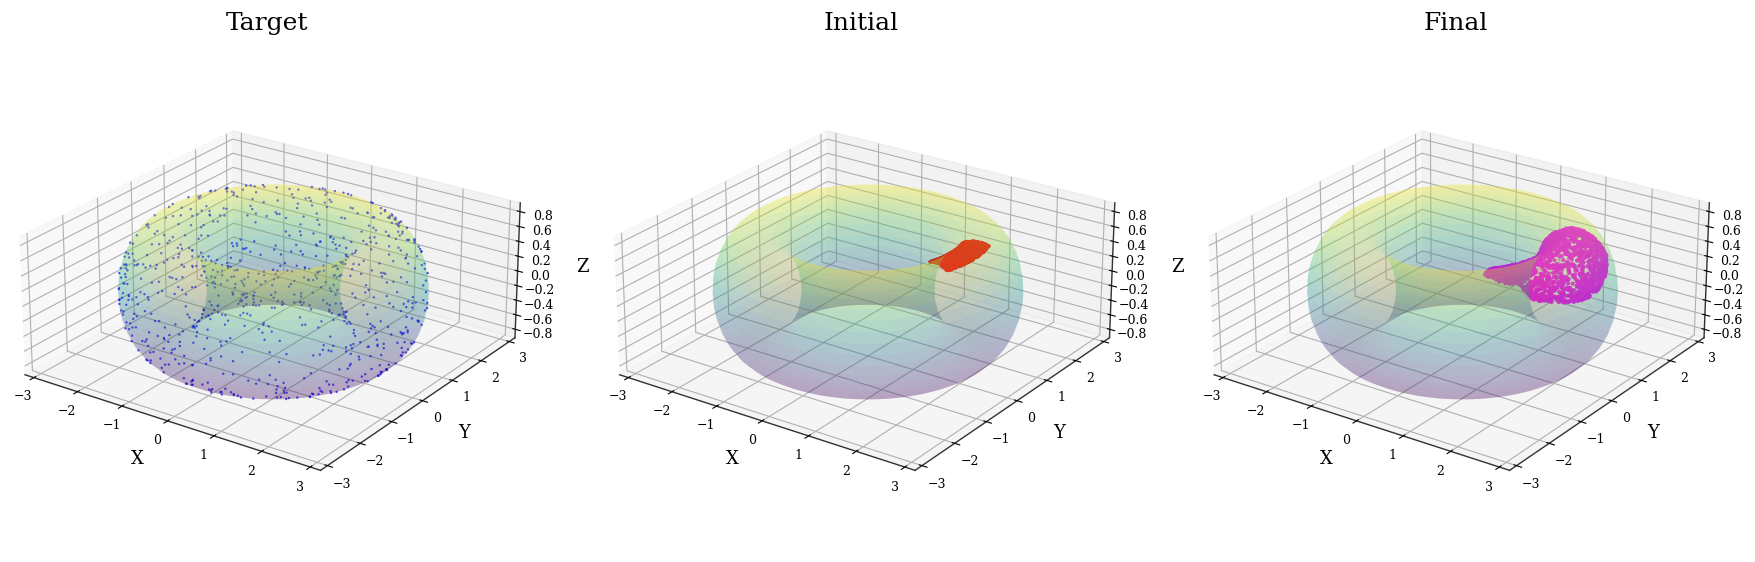

Caption: DMPS on the torus: target samples, localized initial particles, and final transported particles.
Saved: figures/torus/dmps_torus_results.png and figures/torus/dmps_torus_results.pdf


In [4]:
plot_torus_triptych(
    X_tar, X_init, kswgd_result.final, R=cfg.R, r=cfg.r, method='KSWGD',
    stem='figures/torus/kswgd_torus_results',
    caption='KSWGD on the torus: target samples, localized initial particles, and final transported particles.',
    final_color='magenta',
)
plot_torus_triptych(
    X_tar, X_init, dmps_result.final, R=cfg.R, r=cfg.r, method='DMPS',
    stem='figures/torus/dmps_torus_results',
    caption='DMPS on the torus: target samples, localized initial particles, and final transported particles.',
    final_color='magenta',
)


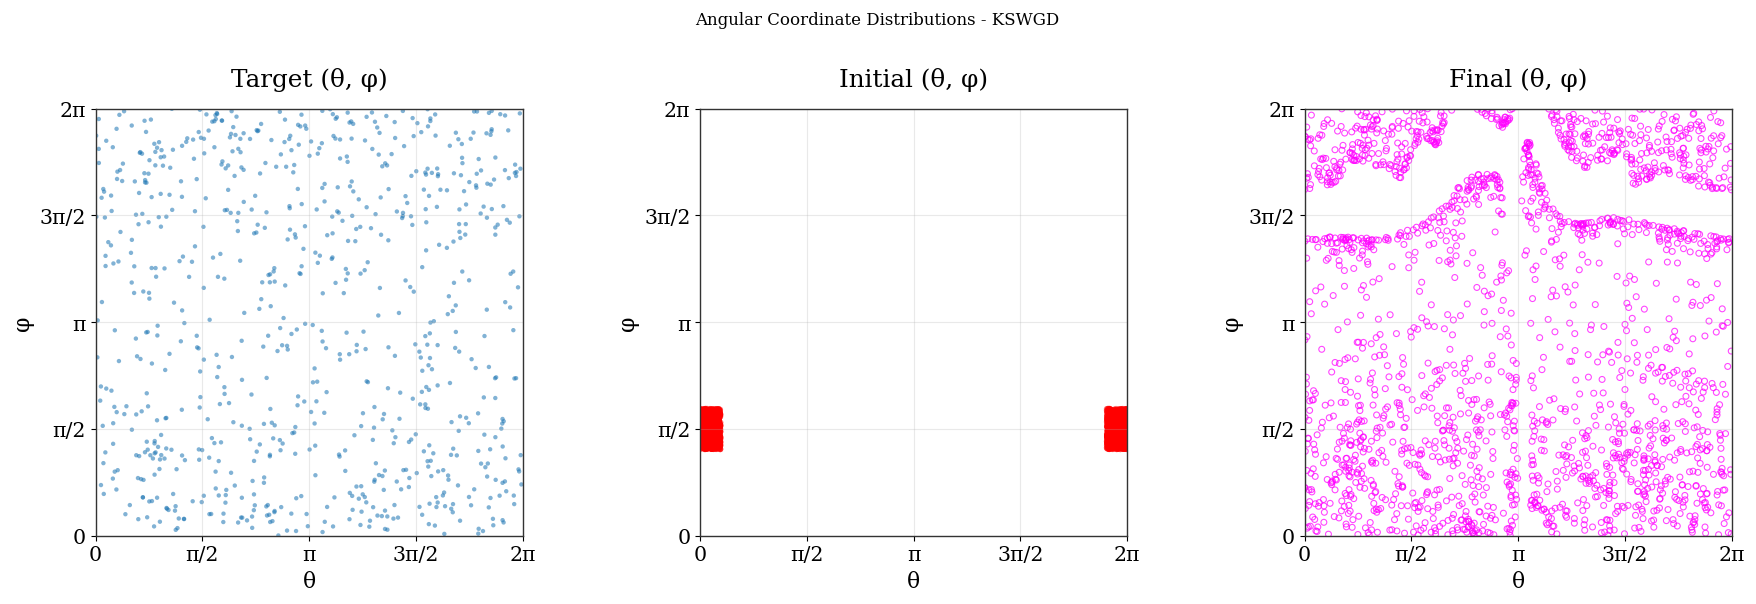

Caption: Angular-coordinate comparison for KSWGD: target, localized initialization, and final particles.
Saved: figures/torus/kswgd_angular_coordinates.png and figures/torus/kswgd_angular_coordinates.pdf


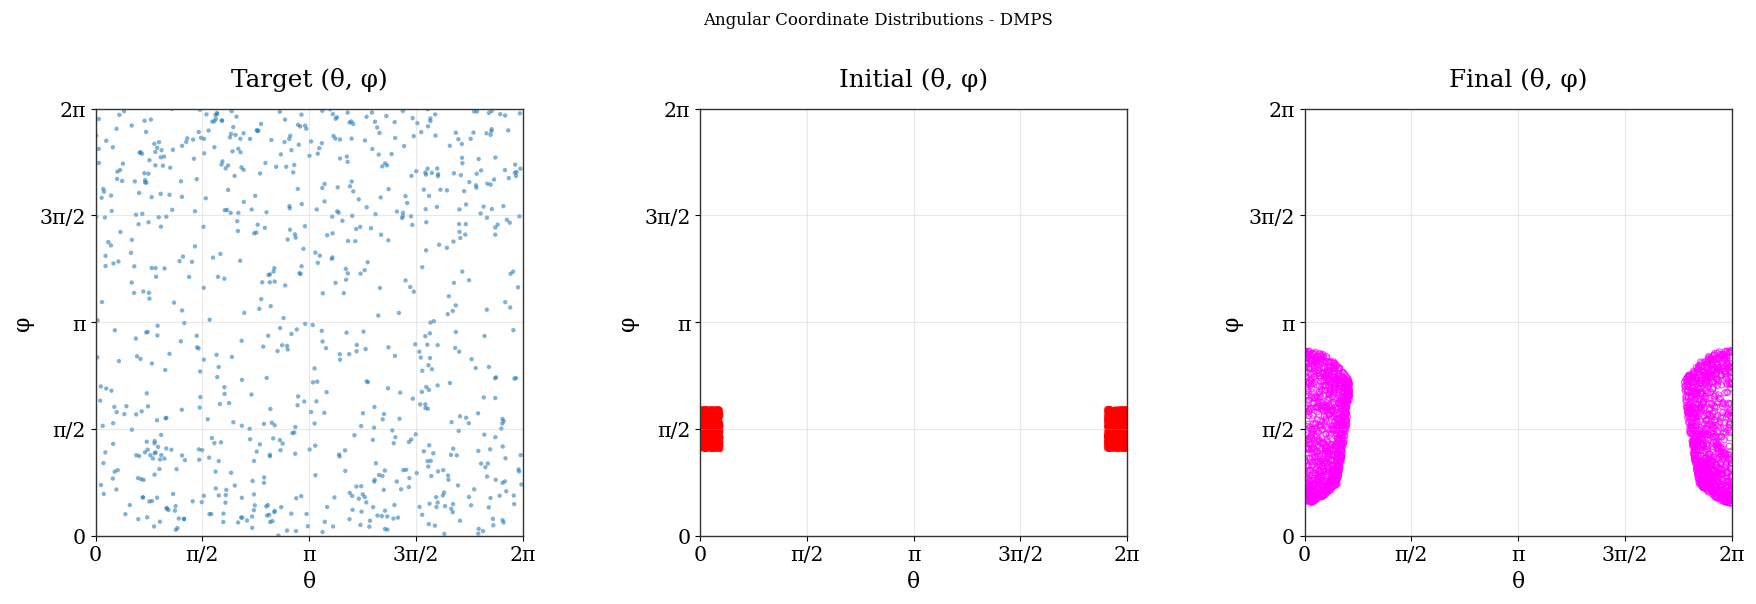

Caption: Angular-coordinate comparison for DMPS: target, localized initialization, and final particles.
Saved: figures/torus/dmps_angular_coordinates.png and figures/torus/dmps_angular_coordinates.pdf


In [5]:
theta_kswgd, phi_kswgd = cartesian_to_angles(kswgd_result.final, cfg.R, cfg.r)
theta_dmps, phi_dmps = cartesian_to_angles(dmps_result.final, cfg.R, cfg.r)
plot_torus_angular(
    theta_tar, phi_tar, theta_init, phi_init, theta_kswgd, phi_kswgd,
    method='KSWGD', stem='figures/torus/kswgd_angular_coordinates',
    caption='Angular-coordinate comparison for KSWGD: target, localized initialization, and final particles.',
)
plot_torus_angular(
    theta_tar, phi_tar, theta_init, phi_init, theta_dmps, phi_dmps,
    method='DMPS', stem='figures/torus/dmps_angular_coordinates',
    caption='Angular-coordinate comparison for DMPS: target, localized initialization, and final particles.',
)


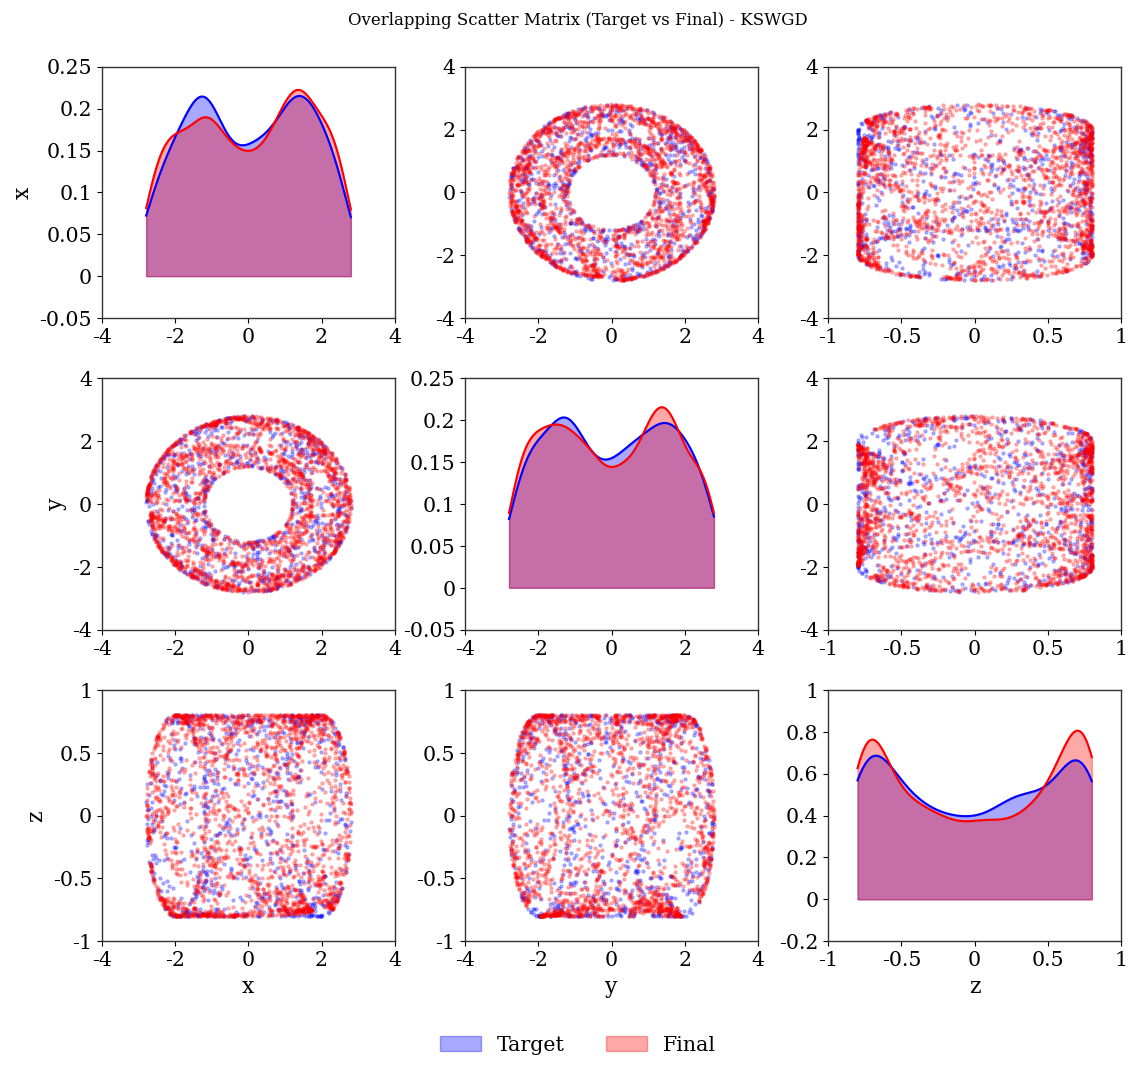

Caption: KDE scatter matrix comparing the torus target with final KSWGD particles.
Saved: figures/torus/kswgd_overlapping_scatter_matrix_kde.png and figures/torus/kswgd_overlapping_scatter_matrix_kde.pdf


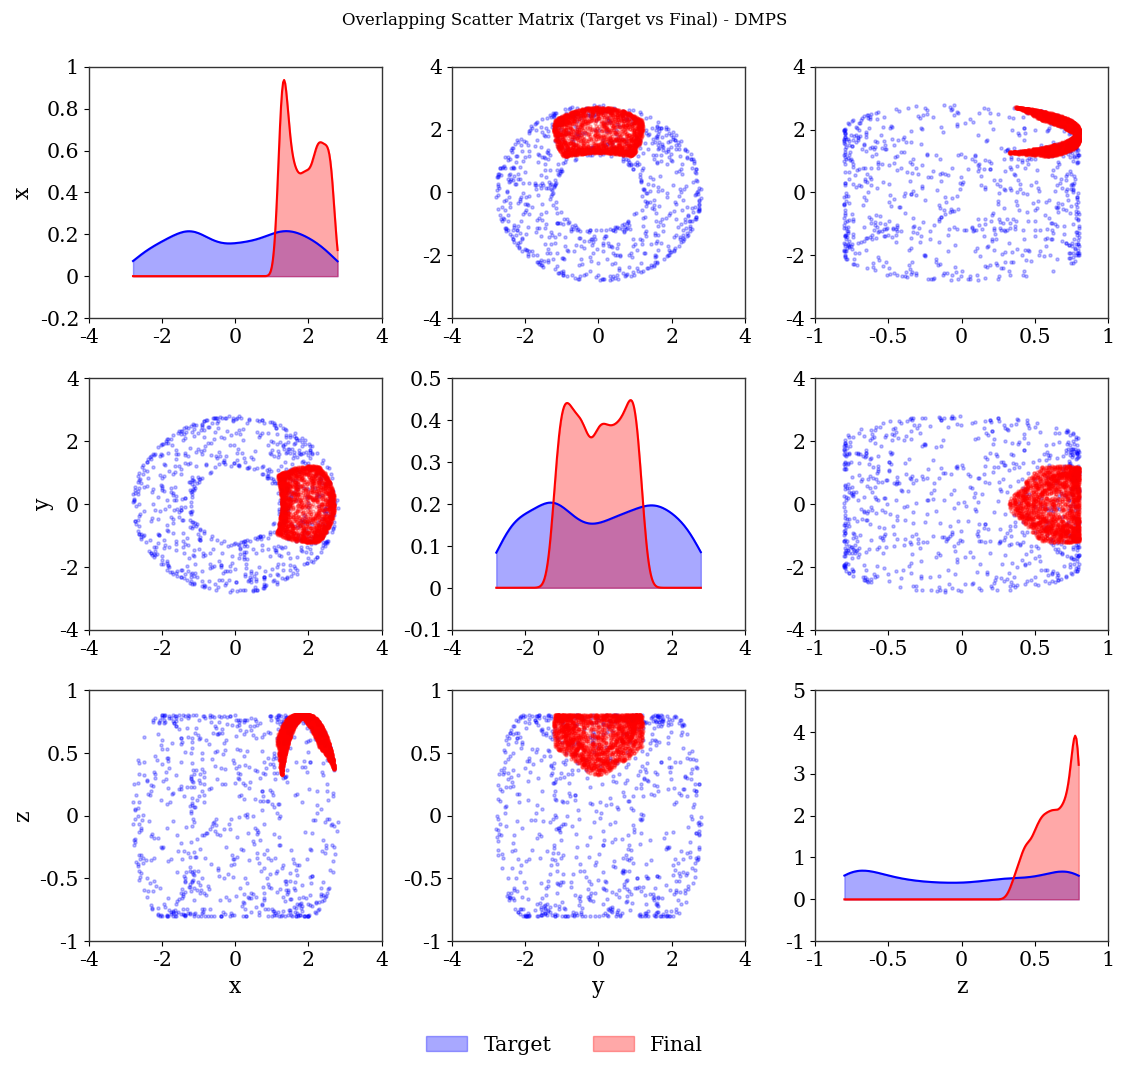

Caption: KDE scatter matrix comparing the torus target with final DMPS particles.
Saved: figures/torus/dmps_overlapping_scatter_matrix_kde.png and figures/torus/dmps_overlapping_scatter_matrix_kde.pdf


In [6]:
plot_torus_overlap_matrix(
    X_tar, kswgd_result.final, method='KSWGD', mode='kde',
    stem='figures/torus/kswgd_overlapping_scatter_matrix_kde',
    caption='KDE scatter matrix comparing the torus target with final KSWGD particles.',
)
plot_torus_overlap_matrix(
    X_tar, dmps_result.final, method='DMPS', mode='kde',
    stem='figures/torus/dmps_overlapping_scatter_matrix_kde',
    caption='KDE scatter matrix comparing the torus target with final DMPS particles.',
)
